# De píxeles a patches: cómo una imagen entra en un Transformer

**Facsímil 11 · IA multimodal y percepción** — capítulo 2 (de píxeles a patches: cómo una imagen se
convierte en representación).

Los Transformers nacieron para texto. ¿Cómo es que hoy entienden imágenes? El truco, sencillo y
brillante, es el que descubres en este cuaderno: una foto no se mete píxel a píxel, se **trocea en
parches**, y cada parche se convierte en un vector, igual que una frase se trocea en *tokens*. Lo haces a
mano, con NumPy, y compruebas que una imagen es, para el modelo, **una secuencia de vectores**. Esa idea
—imagen = secuencia de parches— es la llave de los *Vision Transformers* (ViT) y, sobre ellos, de CLIP,
los modelos visión-lenguaje y medio sistema multimodal.

### Qué vas a aprender
- Por qué un Transformer de texto, casi sin cambios, sirve para imágenes.
- Cómo se **trocea** una imagen en parches y cómo cada parche se **aplana** en un vector.
- Qué papel juegan el **embedding lineal** y los **embeddings de posición** (para no perder dónde estaba
  cada parche).
- El compromiso **tamaño de parche** ↔ longitud de la secuencia ↔ coste.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

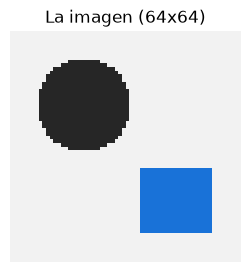

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# Imagen sintetica reconocible (64x64, color): fondo claro, un circulo y un cuadrado.
H = W = 64
img = np.ones((H, W, 3)) * 0.95
yy, xx = np.mgrid[0:H, 0:W]
img[(yy-20)**2 + (xx-20)**2 < 13**2] = [0.15, 0.15, 0.15]   # circulo oscuro
img[38:56, 36:56] = [0.10, 0.45, 0.85]                       # cuadrado azul
plt.figure(figsize=(3,3)); plt.imshow(img); plt.title("La imagen (64x64)"); plt.axis("off"); plt.show()


## 1. El problema: el texto es una secuencia, la imagen una cuadrícula

Un Transformer espera una **secuencia** de vectores (las palabras de una frase). Una imagen, en cambio,
es una cuadrícula 2D de píxeles. No puedes meter los píxeles uno a uno: una imagen pequeña de 224×224
tiene 50.000 píxeles, y la atención (que compara cada elemento con todos) costaría una fortuna. La
solución del *Vision Transformer*: agrupar los píxeles en **parches** (trozos de, digamos, 16×16) y
tratar cada parche como un «token». Así una imagen se convierte en una secuencia corta y manejable.


## 2. Trocear en parches

Cortamos la imagen en una rejilla de parches de 16×16 píxeles. Una imagen de 64×64 da 4×4 = **16
parches**. Cada parche es un trocito de imagen; en cuanto los pongamos en fila, serán nuestra
«secuencia», como las palabras de una frase.


La imagen 64x64 se ha partido en 16 parches de 16x16 pixeles.


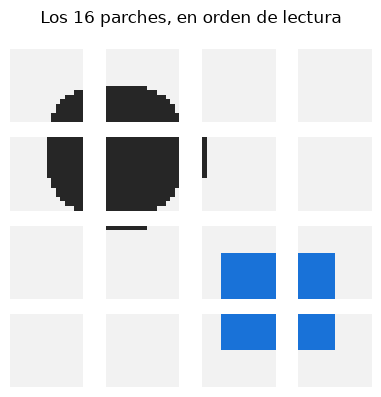

In [2]:
P = 16
n = H // P
parches = img.reshape(n, P, W//P, P, 3).swapaxes(1, 2).reshape(n*n, P, P, 3)
print(f"La imagen 64x64 se ha partido en {parches.shape[0]} parches de {P}x{P} pixeles.")
fig, axes = plt.subplots(n, n, figsize=(4,4))
for k, ax in enumerate(axes.flat):
    ax.imshow(parches[k]); ax.axis("off")
fig.suptitle(f"Los {n*n} parches, en orden de lectura"); plt.tight_layout(); plt.show()


## 3. Cada parche, un vector

Aplanamos cada parche: 16×16 píxeles × 3 colores = **768 números**. La imagen entera deja de ser una
cuadrícula de píxeles y pasa a ser una **secuencia de 16 vectores de 768**. Eso es exactamente lo que
recibe un Transformer: una secuencia, igual que con el texto (donde cada *token* es un vector).


In [3]:
secuencia = parches.reshape(n*n, -1)
print("Forma de la secuencia (parches x dimensiones):", secuencia.shape)
print(f"La imagen es ahora una SECUENCIA de {secuencia.shape[0]} vectores de {secuencia.shape[1]} numeros.")
print("\nParche 0 (esquina sup-izq, parte del fondo claro), primeros 6 numeros:", np.round(secuencia[0][:6], 2))
print("Parche 5 (zona del circulo oscuro), primeros 6 numeros:        ", np.round(secuencia[5][:6], 2))
print("Sus vectores son distintos: ahi esta la informacion que el modelo usara para distinguir formas.")


Forma de la secuencia (parches x dimensiones): (16, 768)
La imagen es ahora una SECUENCIA de 16 vectores de 768 numeros.

Parche 0 (esquina sup-izq, parte del fondo claro), primeros 6 numeros: [0.95 0.95 0.95 0.95 0.95 0.95]
Parche 5 (zona del circulo oscuro), primeros 6 numeros:         [0.15 0.15 0.15 0.15 0.15 0.15]
Sus vectores son distintos: ahi esta la informacion que el modelo usara para distinguir formas.


## 4. Dos detalles que faltan: embedding lineal y posición

En un ViT real, cada vector de parche pasa por una **proyección lineal aprendida** (un *embedding*, como
con las palabras) que lo lleva a la dimensión del modelo. Y hay un problema: al poner los parches en
fila, **se pierde dónde estaba cada uno** (la atención no sabe de posiciones por sí sola). La solución es
sumar a cada parche un **embedding de posición**: un vector que codifica «yo soy el parche de la fila 2,
columna 3». Lo simulamos para ver la idea: sin posición, dos parches idénticos en sitios distintos serían
indistinguibles; con posición, no.


In [4]:
# embedding de posicion simulado: un valor distinto por parche
pos = np.linspace(-1, 1, n*n).reshape(-1, 1)
secuencia_con_pos = np.hstack([secuencia, pos])
print("Sin posicion, el parche 0 y un parche identico en otra esquina tendrian el MISMO vector.")
print("Con posicion, cada parche lleva ademas su 'coordenada':")
print("  parche 0 -> coordenada", round(float(pos[0, 0]), 2))
print("  parche 15 -> coordenada", round(float(pos[15, 0]), 2))
print("Asi el modelo sabe no solo QUE hay en cada parche, sino DONDE esta.")


Sin posicion, el parche 0 y un parche identico en otra esquina tendrian el MISMO vector.
Con posicion, cada parche lleva ademas su 'coordenada':
  parche 0 -> coordenada -1.0
  parche 15 -> coordenada 1.0
Asi el modelo sabe no solo QUE hay en cada parche, sino DONDE esta.


## 5. Experimento: tamaño de parche, longitud y coste

El tamaño de parche es una palanca de diseño. Parches **pequeños** dan más detalle pero una secuencia
**más larga** (y la atención cuesta del orden del cuadrado de la longitud). Parches **grandes**, lo
contrario. Lo medimos para una imagen de 224×224 (un tamaño típico), viendo cómo cambian el número de
parches y el coste relativo de la atención.


In [5]:
print("imagen 224x224 | tam. parche | nº de parches | coste atencion (~ parches^2)")
base = None
for tam in [32, 16, 8]:
    n_p = (224 // tam) ** 2
    coste = n_p ** 2
    if base is None: base = coste
    print(f"               |    {tam:>2}x{tam:<2}    |     {n_p:>4}      |  x{coste/base:>5.1f}")
print("\nParches mas pequenos = mas detalle, pero secuencia mas larga y atencion mucho mas cara.")
print("Elegir el tamano de parche es el mismo compromiso resolucion/coste de siempre.")


imagen 224x224 | tam. parche | nº de parches | coste atencion (~ parches^2)
               |    32x32    |       49      |  x  1.0
               |    16x16    |      196      |  x 16.0
               |     8x8     |      784      |  x256.0

Parches mas pequenos = mas detalle, pero secuencia mas larga y atencion mucho mas cara.
Elegir el tamano de parche es el mismo compromiso resolucion/coste de siempre.


## 6. Pruébalo tú

1. **Cambia el tamaño de parche** a `P = 8`: ahora hay 64 parches más pequeños (más detalle, secuencia más
   larga). Visualízalos.
2. **Mete tu propia imagen** (`plt.imread`) y trocéala. Recuerda redimensionar a un múltiplo de `P`.
3. **Compara vectores:** mira el vector de un parche del círculo y otro del fondo. Su diferencia es la
   materia prima con la que el modelo distingue formas.
4. **Solapamiento:** investiga qué pasa si los parches se solapan un poco (como en algunas variantes).
   ¿Más información redundante? ¿Mejores fronteras?


## 7. Errores comunes

- **Creer que hay «visión por computador» mágica.** No: se trocea y se aplana. Lo potente es la atención
  que viene después (facsímil 3).
- **Olvidar la posición.** Sin embeddings de posición, el modelo no sabe dónde estaba cada parche, y una
  imagen y su versión barajada serían iguales para él.
- **Elegir parches diminutos sin pensar.** La secuencia se dispara y la atención se vuelve carísima. Es un
  compromiso, no «más detalle siempre es mejor».
- **Olvidar el embedding lineal.** Los parches crudos pasan por una proyección aprendida antes de entrar
  al Transformer; no van «tal cual».


## 8. Qué te llevas

- Una imagen entra en un Transformer como una **secuencia de parches**, cada uno convertido en un vector:
  el equivalente visual de los *tokens* de texto.
- Por eso la **misma maquinaria** (atención, capas) sirve para texto e imagen: lo que cambia es la puerta
  de entrada, no el motor. Los **embeddings de posición** conservan el dónde.
- El **tamaño de parche** es un compromiso entre detalle y coste, el mismo de siempre.

**Para seguir:** el capítulo 3 (CLIP) alinea estos vectores de imagen con vectores de texto en un mismo
espacio; el siguiente cuaderno usa una versión simple de esa idea para buscar imágenes por contenido.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*